In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Configure visualization settings
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline
pd.set_option('display.max_columns', None)

In [2]:
# Load dataset
df = pd.read_csv('..\datasets\churn-bigml-80.csv')

# Drop the target label (Churn)
X = df.drop(columns=['Churn'])

# Select purely continuous usage metrics
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols.remove('Area code')  # Area code is categorical despite being numeric

X_usage = X[num_cols]

print("Continuous Usage Features Selected:")
display(X_usage.head())

Continuous Usage Features Selected:


,Account length,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
0,128,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1
1,107,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1
2,137,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0
3,84,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2
4,75,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3


In [3]:
# Standardize features to mean=0, std=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_usage)

# Convert back to DataFrame to verify scaling
X_scaled_df = pd.DataFrame(X_scaled, columns=X_usage.columns)
display(X_scaled_df.head())

,Account length,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
0,0.692163,1.247508,1.579670,0.484868,1.579942,-0.058619,-0.050781,-0.058445,0.857403,-0.469031,0.856707,-0.085020,-0.597527,-0.085681,-0.429172
1,0.161278,1.320985,-0.329918,1.135375,-0.330194,-0.095916,0.147654,-0.095397,1.048458,0.149054,1.049293,1.242179,-0.597527,1.242921,-0.429172
2,0.919686,-0.589414,1.179302,0.685024,1.179465,-1.554439,0.494917,-1.554963,-0.759668,0.200561,-0.758391,0.704125,0.216894,0.698194,-1.191955
3,-0.420168,-0.589414,2.212509,-1.466653,2.212675,-2.718509,-0.596479,-2.718922,-0.084083,-0.572045,-0.084339,-1.304609,1.031314,-1.307995,0.333610
4,-0.647691,-0.589414,-0.235822,0.634985,-0.235772,-1.022461,1.090224,-1.021482,-0.281046,1.076181,-0.281303,-0.049150,-0.597527,-0.045823,1.096392


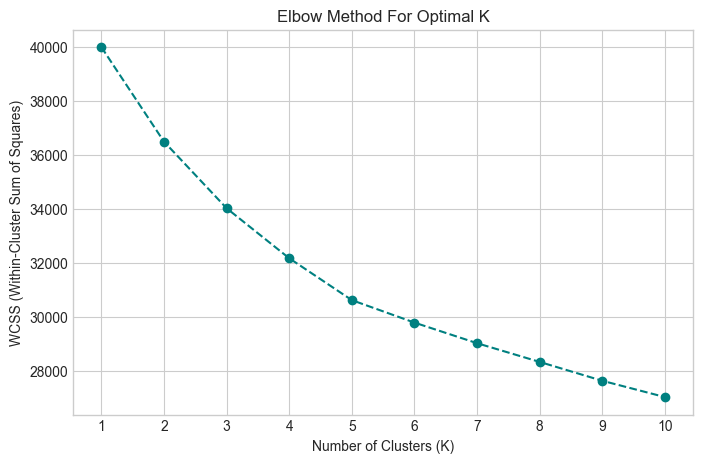

In [4]:
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='teal')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.xticks(k_range)
plt.show()

C:\Users\pijus\AppData\Local\Temp\ipykernel_7928\278783945.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_usage['Cluster'] = cluster_labels


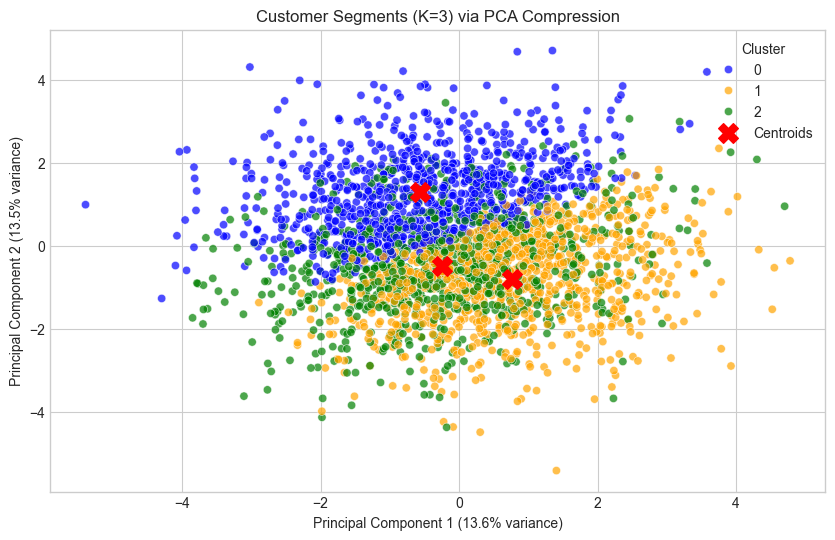

In [6]:
# 1. Fit Final K-Means Model
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Append labels to our original usage dataframe for interpretation
X_usage['Cluster'] = cluster_labels

# 2. Apply PCA to reduce from 14 dimensions to 2
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 3. Plot the 2D Clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_pca[:, 0], 
    y=X_pca[:, 1], 
    hue=cluster_labels, 
    palette=['blue', 'orange', 'green'], 
    alpha=0.7
)

# Plot cluster centers in the PCA space
centers_pca = pca.transform(kmeans_final.cluster_centers_)
plt.scatter(
    centers_pca[:, 0], centers_pca[:, 1], 
    c='red', s=200, marker='X', label='Centroids'
)

plt.title(f'Customer Segments (K={optimal_k}) via PCA Compression')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(title='Cluster')
plt.show()

In [7]:
# Group by the new Cluster label and calculate the mean for each feature
cluster_profiles = X_usage.groupby('Cluster').mean().round(2)

print("Average Usage Profiles by Cluster:")
display(cluster_profiles)

Average Usage Profiles by Cluster:


,Account length,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
Cluster,,,,,,,,,,,,,,,
0,100.31,7.89,175.65,99.77,29.86,247.78,98.72,21.06,176.31,99.87,7.93,10.43,4.56,2.82,1.55
1,98.39,8.68,189.27,100.32,32.18,195.42,101.08,16.61,249.89,100.33,11.25,10.92,4.49,2.95,1.49
2,103.44,7.42,172.63,100.87,29.35,155.59,100.23,13.23,173.21,100.11,7.79,9.27,4.35,2.50,1.65
